In [5]:
# ДЗ
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

### 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

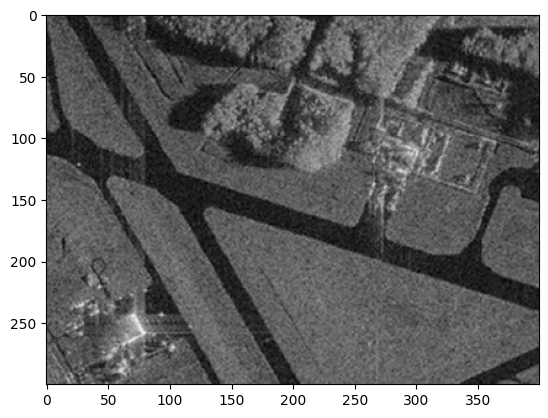

In [7]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")


Запуск для параметров: r=1, T=10
Завершено для (r=1, T=10): Общий размер региона - 15950 пикселей


Запуск для параметров: r=2, T=30
Завершено для (r=2, T=30): Общий размер региона - 21286 пикселей


Запуск для параметров: r=3, T=35
Завершено для (r=3, T=35): Общий размер региона - 90696 пикселей



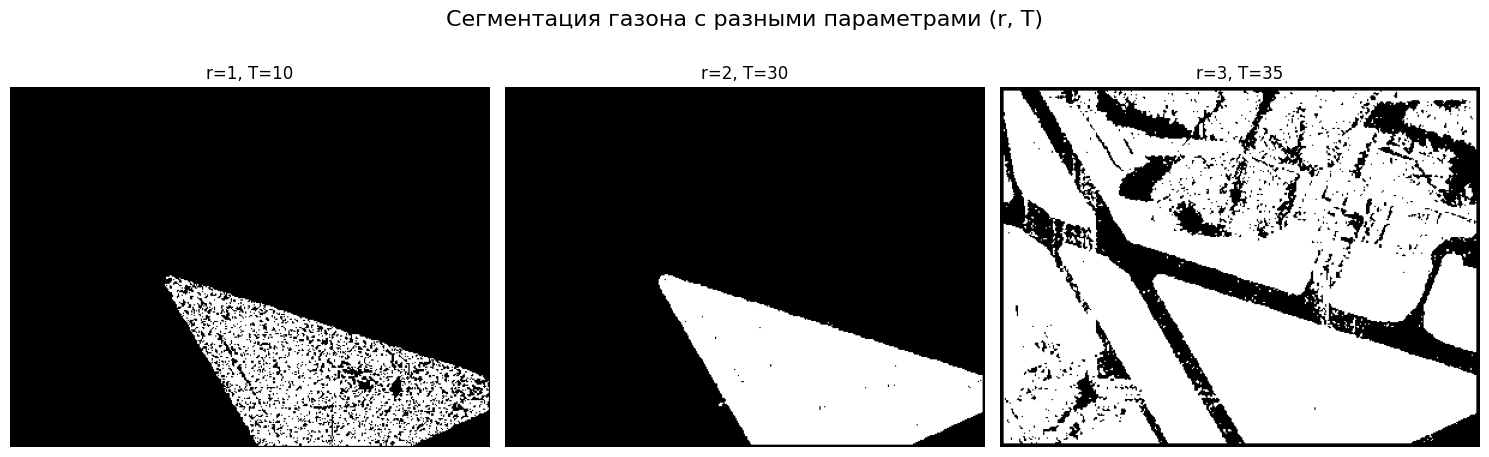

In [8]:
# Функция проверки однородности на основе среднего
def homo_average(img, mask, point, T):
    # Вычисление среднего значения в текущем регионе
    region_values = img[mask > 0]
    if len(region_values) == 0:
        return False  # На случай пустой маски
    av_val = region_values.sum() / len(region_values)
    # Проверка, укладывается ли значение пикселя в порог
    if abs(av_val - img[point]) <= T:
        return True
    return False

# Алгоритм роста регионов
def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    iteration = 0
    while count > 0:
        iteration += 1
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i, j] == 0 and np.sum(mask[i - r:i + r + 1, j - r:j + r + 1]) > 0:
                    if homo_fun(image, mask, (i, j), T):
                        local_mask[i, j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
    final_size = np.count_nonzero(mask)
    print(f"Завершено для (r={r}, T={T}): Общий размер региона - {final_size} пикселей\n")
    return mask * 255

# Список пар параметров (r, T)
param_pairs = [(1, 10), (2, 30), (3, 35)]
seed_point = (250, 250)

fig, axs = plt.subplots(1, len(param_pairs), figsize=(15, 5))
fig.suptitle("Сегментация газона с разными параметрами (r, T)", fontsize=16)

# Запуск для каждой пары и визуализация
for idx, (r, T) in enumerate(param_pairs):
    print(f"\nЗапуск для параметров: r={r}, T={T}")
    mask = region_growing(image_gray, seed_point, homo_average, r, T)
    
    axs[idx].imshow(mask, cmap="gray")
    axs[idx].set_title(f"r={r}, T={T}")
    axs[idx].axis('off')

plt.tight_layout()
plt.show()

### 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.

#### K-Means с разными значениями K

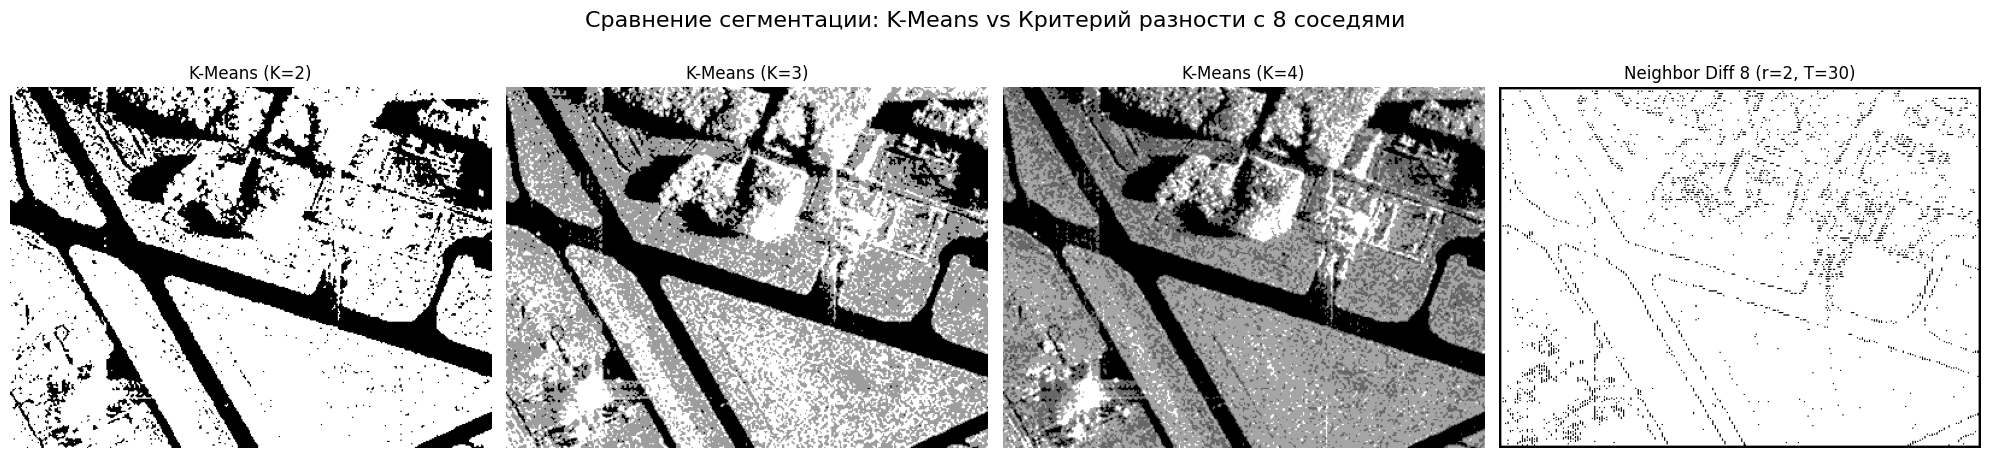

In [9]:
# Функция для применения K-Means с заданным K
def apply_kmeans(image_gray, K):
    z = np.float32(image_gray.reshape((-1, 1)))
    
    # Критерий остановки: max_iter=100, eps=0.05
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.05)
    
    # Запуск K-Means
    ret, label, center = cv2.kmeans(z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Постобработка: центры в uint8, замена пикселей на центры кластеров
    center = np.uint8(center)
    res = center[label.flatten()]
    res = res.reshape(image_gray.shape)
    
    return res

# Критерий разности с 8 соседями
def homo_neighbor_diff_8(img, mask, point, T):
    i, j = point
    height, width = img.shape
    
    current_val = img[i, j].astype(np.int32)
    for di, dj in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
        ni, nj = i + di, j + dj
        if 0 <= ni < height and 0 <= nj < width and mask[ni, nj] > 0:
            neighbor_val = img[ni, nj].astype(np.int32)
            if abs(current_val - neighbor_val) > T:
                return False
    return True

# Алгоритм роста регионов
def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i, j] == 0 and np.sum(mask[i - r:i + r + 1, j - r:j + r + 1]) > 0:
                    if homo_fun(image, mask, (i, j), T):
                        local_mask[i, j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
    return mask * 255

# Диапазон K для K-Means: от 2 до 4
k_values = [2, 3, 4]

# Параметры для region_growing с homo_neighbor_diff_8
seed_point = (250, 250)
r = 2
T = 30
mask_neighbor = region_growing(image_gray, seed_point, homo_neighbor_diff_8, r, T)

# Создание фигуры с 4 subplots: 3 для K-Means + 1 для neighbor_diff_8
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Сравнение сегментации: K-Means vs Критерий разности с 8 соседями", fontsize=16)

# Визуализация K-Means
for idx, K in enumerate(k_values):
    segmented = apply_kmeans(image_gray, K)
    axs[idx].imshow(segmented, cmap="gray")
    axs[idx].set_title(f"K-Means (K={K})")
    axs[idx].axis('off')

# Визуализация для критерия соседей
axs[3].imshow(mask_neighbor, cmap="gray")
axs[3].set_title(f"Neighbor Diff 8 (r={r}, T={T})")
axs[3].axis('off')

plt.tight_layout()
plt.show()

### 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

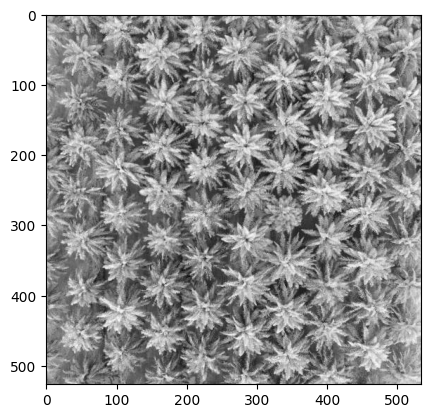

In [10]:
image = cv2.imread('palm_1.JPG')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

Параметры (blur=3, dist_mask=3, coeff=0.5): Подсчёт деревьев = 116
Параметры (blur=3, dist_mask=5, coeff=0.6): Подсчёт деревьев = 45
Параметры (blur=3, dist_mask=3, coeff=0.7): Подсчёт деревьев = 14


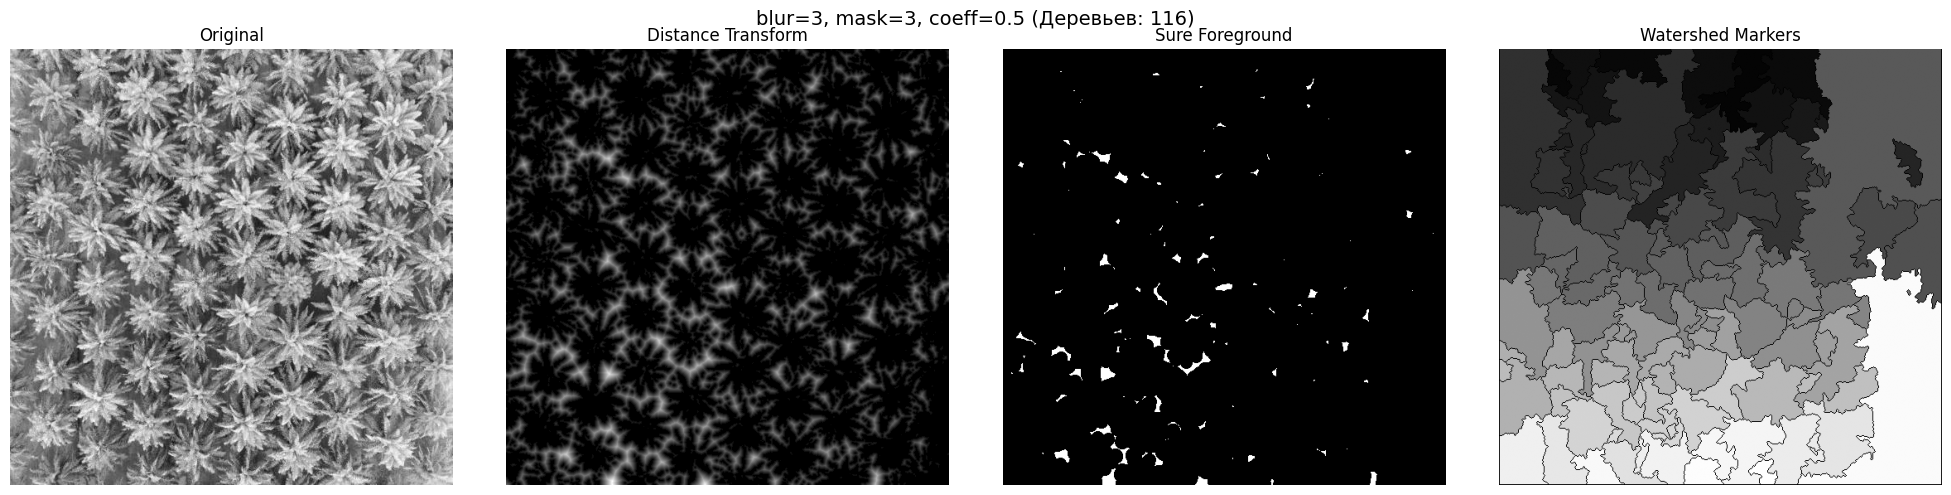

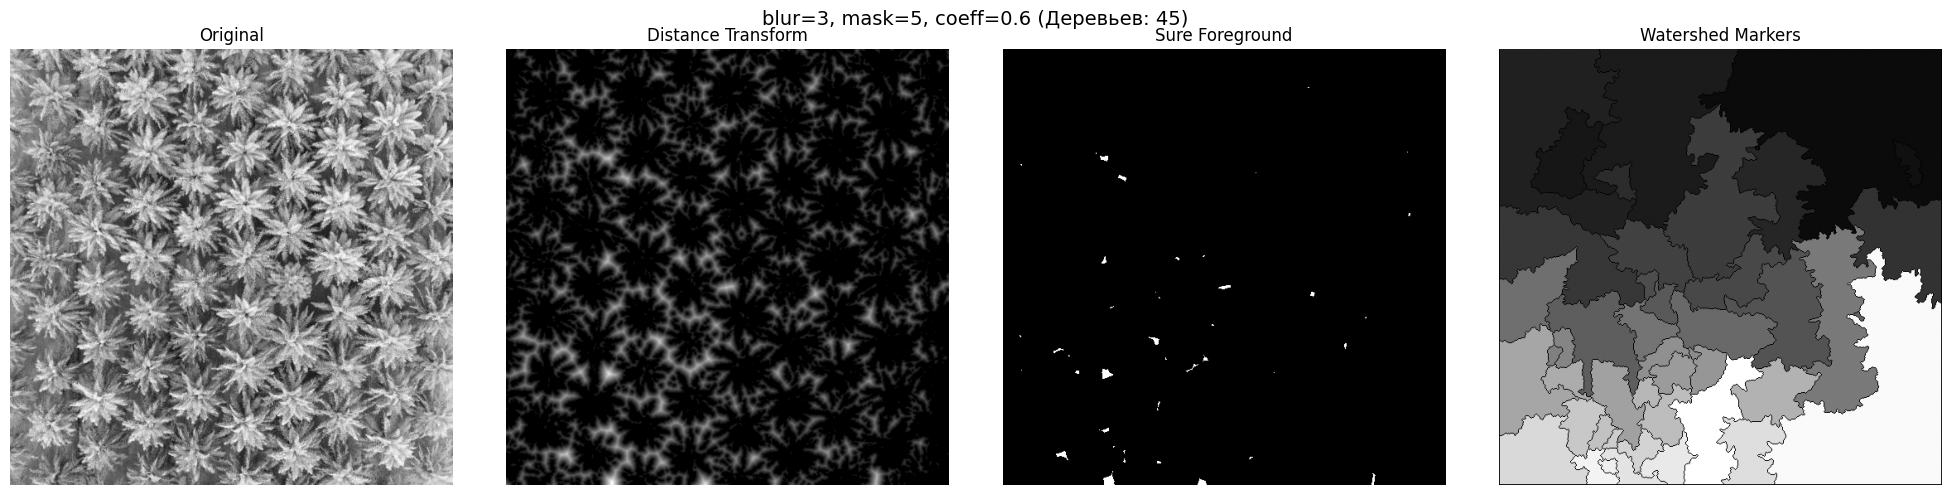

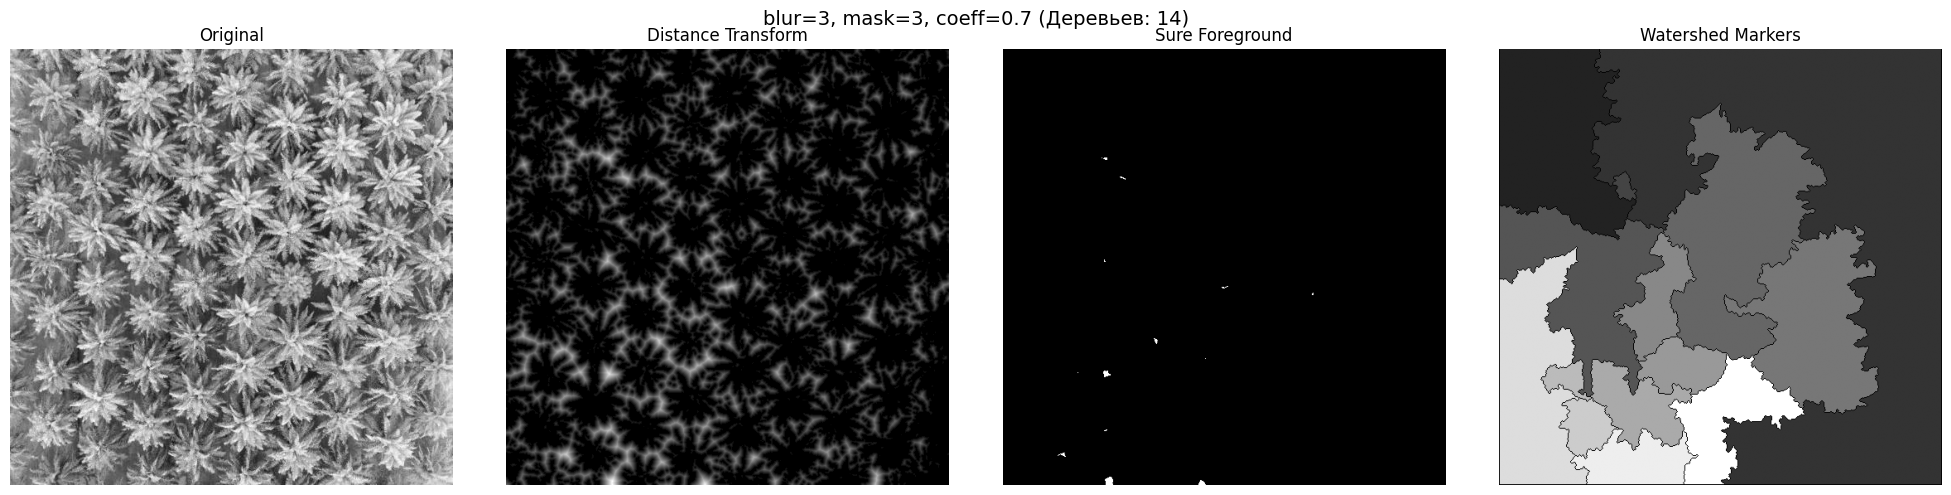

In [11]:
image = cv2.imread('palm_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Функция для применения watershed с заданными параметрами (возвращаем промежуточные: dist, sure_fg, markers)
def apply_watershed(image, image_gray, blur_ksize, dist_mask, thresh_coeff):
    # Для снижения шума
    blurred = cv2.GaussianBlur(image_gray, (blur_ksize, blur_ksize), 0)
    
    # Бинаризация Otsu (не возвращаем, как указано)
    ret, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Distance Transform
    dist = cv2.distanceTransform(thresh, cv2.DIST_L2, dist_mask)
    
    # Threshold для sure_fg
    ret, sure_fg = cv2.threshold(dist, thresh_coeff * dist.max(), 255, cv2.THRESH_BINARY)
    sure_fg = sure_fg.astype(np.uint8)
    
    # Connected Components
    ret, markers = cv2.connectedComponents(sure_fg)
    
    # Watershed
    markers = cv2.watershed(image, markers)
    
    # Подсчёт деревьев
    unique = np.unique(markers)
    count = len(unique) - 1
    
    print(f"Параметры (blur={blur_ksize}, dist_mask={dist_mask}, coeff={thresh_coeff}): Подсчёт деревьев = {count}")
    
    # Нормализация dist для визуализации
    dist_norm = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX)
    
    return dist_norm, sure_fg, markers, count

# Список конфигураций параметров
param_configs = [
    {'blur_ksize': 3, 'dist_mask': 3, 'thresh_coeff': 0.5},
    {'blur_ksize': 3, 'dist_mask': 5, 'thresh_coeff': 0.6},
    {'blur_ksize': 3, 'dist_mask': 3, 'thresh_coeff': 0.7}
]

# Словарь для результатов
results = {}

for config in param_configs:
    dist_norm, sure_fg, markers, count = apply_watershed(image, image_gray, **config)
    name = f"blur={config['blur_ksize']}, mask={config['dist_mask']}, coeff={config['thresh_coeff']}"
    results[name] = {'dist_norm': dist_norm, 'sure_fg': sure_fg, 'markers': markers, 'count': count}

# Визуализация
for name, res in results.items():
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"{name} (Деревьев: {res['count']})", fontsize=14)
    
    # Original
    axes[0].imshow(image_gray, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    # Distance Transform (norm)
    axes[1].imshow(res['dist_norm'], cmap='gray')
    axes[1].set_title('Distance Transform')
    axes[1].axis('off')
    
    # Sure Foreground
    axes[2].imshow(res['sure_fg'], cmap='gray')
    axes[2].set_title('Sure Foreground')
    axes[2].axis('off')
    
    # Final Markers
    axes[3].imshow(res['markers'], cmap='gray')
    axes[3].set_title('Watershed Markers')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()